# Exercise: Predict T-Shirt Size (Multiclass Classification)

**Scenario:** You run an online clothing store, and your #1 headache is **returns** — people order the wrong size, ship it back, and everyone's sad. 😩 So you collect each customer's **height** and **weight** and want to recommend the right T-shirt size automatically.

Sizes come in **three** flavours: **S**, **M**, **L**. Since each customer gets **exactly one** of three labels, this is a **multiclass classification** problem — perfect for `LogisticRegression`.

Columns in `tshirt_sizes.csv`:
- `height_cm` — height in centimetres
- `weight_kg` — weight in kilograms
- `size` — the T-shirt size they actually wear (`S`, `M`, or `L`)

---
> This is the **solution** notebook. No peeking until you've wrestled with `exercise_problem_statement_multiclass.ipynb` yourself! 🙈

## Step 1 — Load the data

In [1]:
import pandas as pd

df = pd.read_csv("tshirt_sizes.csv")
df.head()

,height_cm,weight_kg,size
0,159.8,62.8,S
1,164.6,50.5,S
2,179.2,65.7,L
3,156.8,54.3,S
4,173.6,62.3,M


In [2]:
# how many customers of each size?
df['size'].value_counts()

size
S    45
L    45
M    45
Name: count, dtype: int64

## Step 2 — Look at the data first

Scatter **height vs weight**, coloured by size. Bigger people wear bigger shirts (shocking 😄), but the sizes **blend into each other** at the borders — that's where mistakes will happen.

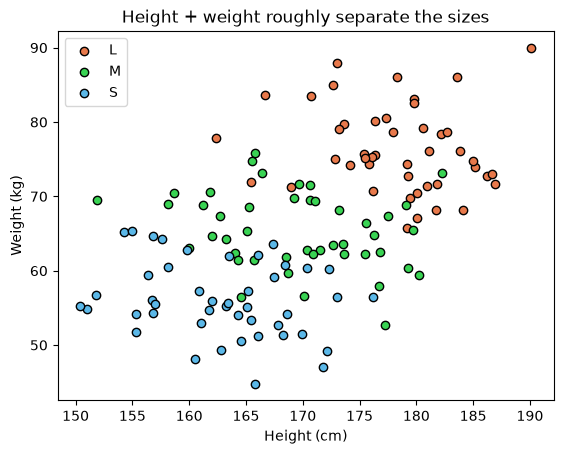

In [3]:
import matplotlib.pyplot as plt

colors = {'S': '#5BB8E8', 'M': '#39D353', 'L': '#E8794B'}
for name, group in df.groupby('size'):
    plt.scatter(group.height_cm, group.weight_kg,
                color=colors[name], edgecolor='k', label=name)
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height + weight roughly separate the sizes")
plt.legend()
plt.show()

## Step 3 — Features (X) and target (y)

In [4]:
X = df[['height_cm', 'weight_kg']]
y = df['size']

print("X shape:", X.shape)
print("Classes:", list(y.unique()))

X shape: (135, 2)
Classes: ['S', 'L', 'M']


## Step 4 — Train / test split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])

Training rows: 108
Testing rows:  27


## Step 5 — Train the multiclass model

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

print("Learned classes:", model.classes_)

Learned classes: ['L' 'M' 'S']


## Step 6 — Predict on the test set

In [7]:
y_pred = model.predict(X_test)

compare = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred})
compare.head(10)

,actual,predicted
0,M,M
1,S,S
2,M,M
3,S,M
4,M,M
5,S,S
6,S,S
7,M,M
8,S,S
9,S,M


## Step 7 — Accuracy

In [8]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy on the test set: {accuracy:.2f}")

Accuracy on the test set: 0.89


## Step 8 — Confusion matrix

A 3×3 grid. We line the labels up as **S → M → L** so the sizes read in order. Watch where the off-diagonal mistakes land.

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

size_order = ['S', 'M', 'L']
cm = confusion_matrix(y_test, y_pred, labels=size_order)
print(cm)

[[8 2 0]
 [0 9 1]
 [0 0 7]]


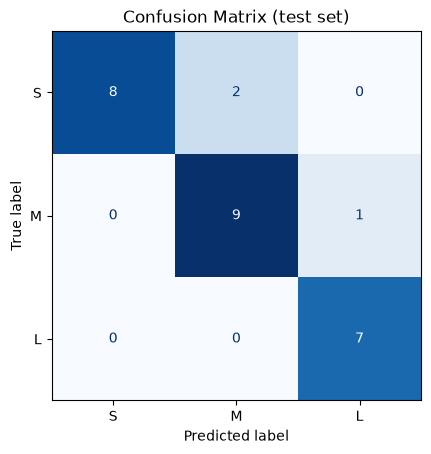

In [10]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=size_order)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (test set)')
plt.show()

Notice the mistakes only happen between **neighbouring** sizes (S↔M, M↔L) — the model never confuses an **S** with an **L**. That makes sense: nobody's borderline between tiny and huge!

## Step 9 — Classification report

Per-size **precision / recall / f1**, so you can see which size the model struggles with most.

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, labels=size_order))

              precision    recall  f1-score   support

           S       1.00      0.80      0.89        10
           M       0.82      0.90      0.86        10
           L       0.88      1.00      0.93         7

    accuracy                           0.89        27
   macro avg       0.90      0.90      0.89        27
weighted avg       0.90      0.89      0.89        27



## Step 10 — Recommend a size for a new customer

A new shopper is **178 cm** and **74 kg**. Which size should the site suggest?

In [12]:
new_customer = pd.DataFrame([{'height_cm': 178, 'weight_kg': 74}])
print("Recommended size:", model.predict(new_customer)[0])

Recommended size: L


## Recap
- **Multiclass** = pick **one** label from **3+** options (here: S / M / L)
- `LogisticRegression` handles it with no special setup
- A **confusion matrix** reveals *which* classes get mixed up (here: only neighbours)
- A **classification report** gives precision / recall / f1 **per size**
- Fewer wrong-size shipments = fewer returns = happier customers 🎉